# Week 3 — Fluid Mechanics II: Continuity, Circulation, and Bernoulli

**OE 754 / 854 — Ocean Waves & Tides**

Week 2 gave us forces on a continuum and the material derivative. This week concludes
our introduction to fluid mechanics:

1. **Continuity** and the **Reynolds transport theorem**, the rule that lets
   us write a conservation law for a moving blob of fluid as a statement about a fixed
   control volume.
2. **Circulation** and **Kelvin's theorem**: an inviscid, barotropic fluid under a
   conservative body force keeps the circulation around any material loop constant. If
   the flow starts irrotational, it stays irrotational, whi
   velocity potential.
3. The **velocity potential** $\phi$ and the **streamfunction** $\psi$: two scalars that
   between them carry an entire 2D incompressible irrotational flow.
4. **Bernoulli's equation**, which turns a velocity field into a pressure field.

Everything gets checked numerically. Sign convention throughout the course:
$\vec u = -\nabla\phi$, and in 2D $u = \partial\psi/\partial y$, $v = -\partial\psi/\partial x$.

### Goals

1. Verify the Reynolds transport theorem on a concrete flow, both for a material blob
   and for a fixed control volume.
2. Advect a material loop through a vortex patch and watch the circulation stay put.
3. Build the potential/streamfunction pair for a uniform stream plus a source, and check
   that the two families of curves are orthogonal.
4. Run the Bernoulli trade of pressure for speed along a converging channel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs

g = 9.81

## 1. Continuity and the Reynolds transport theorem

The Reynolds transport theorem says that for any intensive property $b$ carried by the
fluid,

$$\frac{d}{dt}\int_{V_m(t)} \rho b\,dV
  = \int_{V_c} \frac{\partial(\rho b)}{\partial t}\,dV
  + \oint_{S_c} \rho b\,\vec u\cdot\hat n\,dA,$$

where $V_m$ is a **material** volume (moving with the fluid) and $V_c$ a **control**
volume that coincides with it at the instant in question. Set $b = 1$ and impose
conservation of mass and the left side is zero, which for constant $\rho$ leaves

$$\oint_{S_c}\vec u\cdot\hat n\,dA = 0 \quad\Longleftrightarrow\quad \nabla\cdot\vec u = 0.$$

Two numerical statements of the same fact, on the 2D stagnation flow
$\vec u = (\alpha x,\,-\alpha y)$:

- a material blob of fluid deforms but keeps its area;
- the net flux through a fixed rectangle is zero.


material blob, t = 0 to 2.0 s
  initial area  0.196341 m^2
  final area    0.196341 m^2
  max drift     1.09e-14  (relative)

fixed control volume 0.8 m x 0.7 m
  net outward flux  -8.327e-17 m^2/s   (relative to scale 0.48: 1.73e-16)


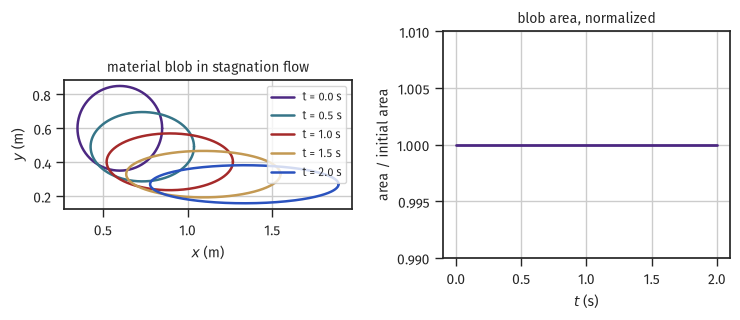

In [2]:
alpha = 0.4          # stagnation-flow strain rate, 1/s


def vel_stag(x, y):
    return alpha*x, -alpha*y


def rk4_step(x, y, dt, vel):
    k1x, k1y = vel(x, y)
    k2x, k2y = vel(x + 0.5*dt*k1x, y + 0.5*dt*k1y)
    k3x, k3y = vel(x + 0.5*dt*k2x, y + 0.5*dt*k2y)
    k4x, k4y = vel(x + dt*k3x, y + dt*k3y)
    return (x + dt/6*(k1x + 2*k2x + 2*k3x + k4x),
            y + dt/6*(k1y + 2*k2y + 2*k3y + k4y))


def polygon_area(x, y):
    # shoelace formula, ordered vertices of a closed polygon
    return 0.5*np.abs(np.sum(x*np.roll(y, -1) - np.roll(x, -1)*y))


# Material blob: a circle of markers advected with the flow
th = np.linspace(0, 2*np.pi, 400, endpoint=False)
xb, yb = 0.6 + 0.25*np.cos(th), 0.6 + 0.25*np.sin(th)
dt, nstep = 0.01, 200
snapshots = [(xb.copy(), yb.copy())]
areas = [polygon_area(xb, yb)]
for n in range(nstep):
    xb, yb = rk4_step(xb, yb, dt, vel_stag)
    areas.append(polygon_area(xb, yb))
    if (n + 1) % 50 == 0:
        snapshots.append((xb.copy(), yb.copy()))
areas = np.array(areas)

print(f'material blob, t = 0 to {nstep*dt:.1f} s')
print(f'  initial area  {areas[0]:.6f} m^2')
print(f'  final area    {areas[-1]:.6f} m^2')
print(f'  max drift     {np.abs(areas/areas[0] - 1).max():.2e}  (relative)')

# Net flux through the four faces of a fixed rectangle, m^2/s
x0, x1, y0, y1 = 0.3, 1.1, 0.2, 0.9
ys = np.linspace(y0, y1, 2001)
xs = np.linspace(x0, x1, 2001)
flux = 0.0
flux += np.trapezoid(vel_stag(np.full_like(ys, x1), ys)[0], ys)    # +x face
flux -= np.trapezoid(vel_stag(np.full_like(ys, x0), ys)[0], ys)    # -x face
flux += np.trapezoid(vel_stag(xs, np.full_like(xs, y1))[1], xs)    # +y face
flux -= np.trapezoid(vel_stag(xs, np.full_like(xs, y0))[1], xs)    # -y face
scale = alpha*max(x1 - x0, y1 - y0)*(x1 - x0 + y1 - y0)
print(f'\nfixed control volume {x1-x0:.1f} m x {y1-y0:.1f} m')
print(f'  net outward flux  {flux:+.3e} m^2/s   (relative to scale {scale:.2f}: '
      f'{abs(flux)/scale:.2e})')

fig, ax = plt.subplots(1, 2, figsize=(fs.fullwidth, 3.3))
for i, (xs, ys) in enumerate(snapshots):
    ax[0].plot(np.r_[xs, xs[0]], np.r_[ys, ys[0]], lw=1.8,
               color=fs.color_list[i % 6], label=f't = {i*50*dt:.1f} s')
ax[0].set_aspect('equal')
ax[0].set_xlabel('$x$ (m)'); ax[0].set_ylabel('$y$ (m)')
ax[0].set_title('material blob in stagnation flow')
ax[0].legend(fontsize=8)

ax[1].plot(np.arange(len(areas))*dt, areas/areas[0], lw=2, color=fs.color_list[0])
ax[1].set_xlabel('$t$ (s)'); ax[1].set_ylabel('area / initial area')
ax[1].set_ylim(0.99, 1.01)
ax[1].set_title('blob area, normalized')
fig.tight_layout()
plt.show()

The blob stretches along $x$ and squashes along $y$ by compensating factors
$e^{\alpha t}$ and $e^{-\alpha t}$, so the area holds to integration error. The fixed
rectangle says the same thing from the other side: whatever comes in one pair of faces
leaves through the other. The transport theorem is what connects the two statements.

## 2. Circulation and Kelvin's theorem

The circulation around a closed curve $C$ is

$$\Gamma = \oint_C \vec u\cdot d\vec l = \int_A (\nabla\times\vec u)\cdot\hat n\,dA
        = \int_A \omega_z\,dA \quad\text{(2D)}.$$

**Kelvin's theorem**: for an inviscid, constant-density fluid under a conservative body
force, $d\Gamma/dt = 0$ around any *material* loop. A wave field generated from rest out
of still water has $\Gamma = 0$ around every loop for all time,
so $\nabla\times\vec u = \vec 0$, so $\vec u = -\nabla\phi$.

Test it on a **Rankine vortex**, a patch of uniform vorticity of radius $R$ sitting in
otherwise irrotational fluid:

$$u_\theta(r) = \begin{cases}\Omega r, & r \le R\\ \Omega R^2/r, & r > R,\end{cases}
\qquad
\omega_z(r) = \begin{cases}2\Omega, & r \le R\\ 0, & r > R.\end{cases}$$

This is a steady solution of Euler's equations: the streamlines are circles and the
pressure gradient supplies the centripetal acceleration. So Kelvin's theorem applies, and
we can test it by dropping material loops into the flow, advecting them, and recomputing
$\Gamma$ at each step. Four loops:

- **A**, a small circle centered on the vortex, entirely inside the core;
- **B**, a large circle centered on the vortex, enclosing the whole core;
- **C**, an off-center circle that straddles the core edge, so it gets wound up by the
  differential rotation;
- **D**, an off-center circle sitting entirely in the irrotational outer region.

Rankine vortex: R = 0.5 m, Omega = 1.2 1/s, vorticity in the core = 2.4 1/s
material loops advected for 1.5 s

material loop              Gamma(0)   Gamma(T)   analytic      drift
--------------------------------------------------------------------
A  inside core               0.4712     0.4712     0.4712   8.33e-16
B  encloses core             1.8849     1.8849     1.8850   0.00e+00
C  straddles the edge        0.4726     0.4726     0.4726   3.75e-06
D  outside, off-axis         0.0000     0.0000     0.0000   9.90e-08


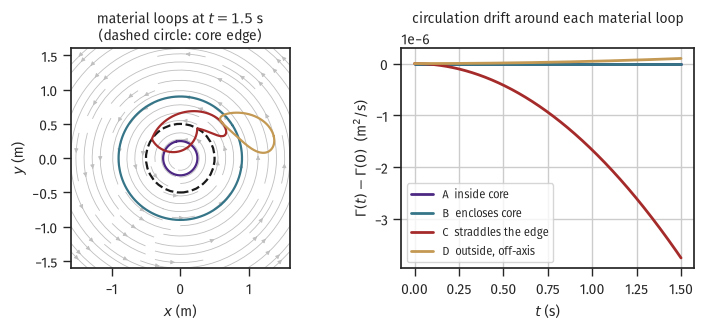

In [6]:
R_core, Omega_core = 0.5, 1.2


def vel_rankine(x, y):
    r = np.hypot(x, y)
    r_safe = np.where(r < 1e-12, 1e-12, r)
    u_th = np.where(r <= R_core, Omega_core*r, Omega_core*R_core**2/r_safe)
    return -u_th*y/r_safe, u_th*x/r_safe


def circulation(x, y):
    # trapezoidal line integral of u.dl around a closed polygon
    u, v = vel_rankine(x, y)
    xs, ys = np.r_[x, x[0]], np.r_[y, y[0]]
    us, vs = np.r_[u, u[0]], np.r_[v, v[0]]
    dx, dy = np.diff(xs), np.diff(ys)
    return np.sum(0.5*(us[:-1] + us[1:])*dx + 0.5*(vs[:-1] + vs[1:])*dy)


def lens_area(d, r1, r2):
    # intersection area of two disks with centers a distance d apart
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return np.pi*min(r1, r2)**2
    a1 = r1**2*np.arccos((d**2 + r1**2 - r2**2)/(2*d*r1))
    a2 = r2**2*np.arccos((d**2 + r2**2 - r1**2)/(2*d*r2))
    a3 = 0.5*np.sqrt((-d + r1 + r2)*(d + r1 - r2)*(d - r1 + r2)*(d + r1 + r2))
    return a1 + a2 - a3


loops = {'A  inside core':        (0.00, 0.0, 0.25),
         'B  encloses core':      (0.00, 0.0, 0.90),
         'C  straddles the edge': (0.45, 0.0, 0.35),
         'D  outside, off-axis':  (1.10, 0.0, 0.30)}

th = np.linspace(0, 2*np.pi, 1200, endpoint=False)
dt, nstep = 0.002, 750
hist, final = {}, {}
for name, (cx, cy, rad) in loops.items():
    x, y = cx + rad*np.cos(th), cy + rad*np.sin(th)
    gam = [circulation(x, y)]
    for _ in range(nstep):
        x, y = rk4_step(x, y, dt, vel_rankine)
        gam.append(circulation(x, y))
    hist[name] = np.array(gam)
    final[name] = (x, y)

print(f'Rankine vortex: R = {R_core} m, Omega = {Omega_core} 1/s, '
      f'vorticity in the core = {2*Omega_core} 1/s')
print(f'material loops advected for {nstep*dt:.1f} s\n')
print(f'{"material loop":<24s}{"Gamma(0)":>11s}{"Gamma(T)":>11s}'
      f'{"analytic":>11s}{"drift":>11s}')
print('-'*68)
for name, (cx, cy, rad) in loops.items():
    gam = hist[name]
    exact = 2*Omega_core*lens_area(np.hypot(cx, cy), rad, R_core)
    print(f'{name:<24s}{gam[0]:>11.4f}{gam[-1]:>11.4f}{exact:>11.4f}'
          f'{abs(gam[-1] - gam[0]):>11.2e}')

fig, ax = plt.subplots(1, 2, figsize=(fs.fullwidth, 3.4))
xg, yg = np.meshgrid(np.linspace(-1.6, 1.6, 220), np.linspace(-1.6, 1.6, 220))
ug, vg = vel_rankine(xg, yg)
ax[0].streamplot(xg, yg, ug, vg, density=0.9, linewidth=0.6, color='0.75',
                 arrowsize=0.6)
ax[0].add_patch(plt.Circle((0, 0), R_core, fill=False, lw=1.6, ls='--', color='k'))
for i, name in enumerate(loops):
    x, y = final[name]
    ax[0].plot(np.r_[x, x[0]], np.r_[y, y[0]], lw=1.6, color=fs.color_list[i])
ax[0].set_aspect('equal'); ax[0].grid(False)
ax[0].set_xlim(-1.6, 1.6); ax[0].set_ylim(-1.6, 1.6)
ax[0].set_xlabel('$x$ (m)'); ax[0].set_ylabel('$y$ (m)')
ax[0].set_title(f'material loops at $t = {nstep*dt:.1f}$ s\n(dashed circle: core edge)')

tt = np.arange(nstep + 1)*dt
for i, (name, gam) in enumerate(hist.items()):
    ax[1].plot(tt, gam - gam[0], lw=2, color=fs.color_list[i], label=name)
ax[1].set_xlabel('$t$ (s)')
ax[1].set_ylabel(r'$\Gamma(t) - \Gamma(0)$  (m$^2$/s)')
ax[1].set_title("circulation drift around each material loop")
ax[1].legend(fontsize=8, loc='lower left')
fig.tight_layout()
plt.show()


Loop C gets badly wound up by the differential rotation and its circulation stays put.
What Kelvin's theorem conserves is the integral of vorticity over the material area the
loop encloses. The shape of the loop and the vorticity at any fixed point are both free
to change.

**Loop B** sits entirely in the irrotational outer region, where
$\nabla\times\vec u = \vec 0$ pointwise, and its circulation is still not zero: it is
$2\pi\Omega R^2$, the full core value. Circulation is a property of what the loop
*encloses*, not of where the loop sits.

**Loop D** is also entirely in the irrotational region, but it encloses nothing, so its
circulation is zero and stays zero even though the velocity along it is nowhere zero.
That is the case the water-wave problem is in.

## 3. Velocity potential and streamfunction

For a 2D incompressible irrotational flow, two scalar fields carry everything:

$$u = -\frac{\partial\phi}{\partial x} = \frac{\partial\psi}{\partial y}, \qquad v = -\frac{\partial\phi}{\partial y} = -\frac{\partial\psi}{\partial x}.$$

Incompressibility gives $\nabla^2\phi = 0$; irrotationality gives $\nabla^2\psi = 0$.
Lines of constant $\psi$ are streamlines, lines of constant $\phi$ are equipotentials,
and the two families cross at right angles because $\nabla\phi\cdot\nabla\psi = 0$
follows directly from the relations above.

Take a uniform stream of speed $U$ plus a point source of strength $m$ (volume flux per
unit depth) at the origin:

$$\phi = -\left(Ux + \frac{m}{2\pi}\ln r\right), \qquad
  \psi = Uy + \frac{m}{2\pi}\theta .$$

The dividing streamline $\psi = m/2$ is a **Rankine half-body**, the classic model for
the bow of a blunt object. Its stagnation point sits at $x = -m/(2\pi U)$, $y = 0$.


velocity from the two scalars, away from the source:
  max |(-dphi/dx) - u_exact| = 3.99e-04 m/s
  max |( dpsi/dy) - u_exact| = 4.05e-04 m/s
  max |(-dphi/dy) - v_exact| = 6.24e-04 m/s
  max |(-dpsi/dx) - v_exact| = 3.93e-04 m/s

orthogonality: max |cos angle between grad phi and grad psi| = 1.01e-02
stagnation point at x = -0.3183 m; speed there = 0.00e+00 m/s


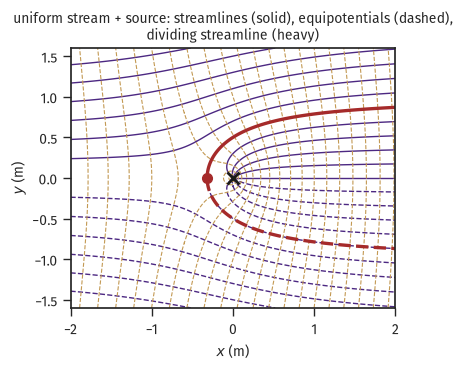

In [4]:
U_inf, m_src = 1.0, 2.0        # stream speed (m/s), source strength (m^2/s)

xg, yg = np.meshgrid(np.linspace(-2.0, 2.0, 401), np.linspace(-1.6, 1.6, 321))
r2 = xg**2 + yg**2
r2 = np.where(r2 < 1e-10, 1e-10, r2)

phi = -(U_inf*xg + (m_src/(2*np.pi))*0.5*np.log(r2))
psi = U_inf*yg + (m_src/(2*np.pi))*np.arctan2(yg, xg)

u_exact = U_inf + (m_src/(2*np.pi))*xg/r2
v_exact = (m_src/(2*np.pi))*yg/r2

# Check that both scalars generate the same velocity field
dx = xg[0, 1] - xg[0, 0]
dy = yg[1, 0] - yg[0, 0]
dphi_dy, dphi_dx = np.gradient(phi, dy, dx)
dpsi_dy, dpsi_dx = np.gradient(psi, dy, dx)

# Mask the source singularity and the arctan2 branch cut on the -x axis,
# where psi jumps by m and finite differences are meaningless
mask = (r2 > 0.09) & ~((xg < 0) & (np.abs(yg) < 1.5*dy))
print('velocity from the two scalars, away from the source:')
print(f'  max |(-dphi/dx) - u_exact| = {np.abs(-dphi_dx - u_exact)[mask].max():.2e} m/s')
print(f'  max |( dpsi/dy) - u_exact| = {np.abs(dpsi_dy - u_exact)[mask].max():.2e} m/s')
print(f'  max |(-dphi/dy) - v_exact| = {np.abs(-dphi_dy - v_exact)[mask].max():.2e} m/s')
print(f'  max |(-dpsi/dx) - v_exact| = {np.abs(-dpsi_dx - v_exact)[mask].max():.2e} m/s')

dot = dphi_dx*dpsi_dx + dphi_dy*dpsi_dy
norm = np.hypot(dphi_dx, dphi_dy)*np.hypot(dpsi_dx, dpsi_dy)
print(f'\northogonality: max |cos angle between grad phi and grad psi| = '
      f'{np.abs(dot/norm)[mask].max():.2e}')

x_stag = -m_src/(2*np.pi*U_inf)
print(f'stagnation point at x = {x_stag:.4f} m; '
      f'speed there = {np.hypot(U_inf + m_src/(2*np.pi*x_stag), 0.0):.2e} m/s')

psi_plot = np.where((xg < 0) & (np.abs(yg) < 0.5*dy), np.nan, psi)

fig, ax = plt.subplots(figsize=(fs.fullwidth*0.8, 3.8))
ax.contour(xg, yg, psi_plot, levels=np.linspace(-3, 3, 31), colors=[fs.color_list[0]],
           linewidths=1.0)
ax.contour(xg, yg, phi, levels=np.linspace(-3, 3, 31), colors=[fs.color_list[3]],
           linewidths=0.8, linestyles='--')
ax.contour(xg, yg, psi_plot, levels=[-m_src/2, m_src/2], colors=[fs.color_list[2]],
           linewidths=2.4)
ax.plot(x_stag, 0, 'o', ms=7, color=fs.color_list[2])
ax.plot(0, 0, 'x', ms=8, mew=2, color='k')
ax.set_aspect('equal'); ax.grid(False)
ax.set_xlabel('$x$ (m)'); ax.set_ylabel('$y$ (m)')
ax.set_title('uniform stream + source: streamlines (solid), equipotentials (dashed),\n'
             'dividing streamline (heavy)')
fig.tight_layout()
plt.show()

Both scalars reproduce the same velocity field to finite-difference error, and the two
contour families meet at right angles everywhere except at the stagnation point, where
$|\vec u| = 0$ and the angle is undefined. The streamfunction of a source is multivalued,
since $\theta$ jumps by $2\pi$ somewhere, and here that cut sits on the negative $x$ axis;
the checks and the plot both step around it. The cut comes from how we wrote $\psi$ down,
not from the flow. The heavy curve is the half-body surface: everything inside it came out
of the source and never mixes with the oncoming stream, so as far as the outer flow is
concerned that curve is a solid wall.

## 4. Bernoulli along a streamline: the converging nozzle

Steady, inviscid, irrotational flow along a horizontal streamline obeys

$$P + \tfrac12\rho u^2 = \text{const},$$

so where continuity speeds the flow up, the pressure has to drop. For a nozzle whose area contracts by a factor $c$: $u_2 = c\,u_1$ and $P_2 = P_1 + \tfrac12\rho\,(u_1^2 - u_2^2)$. The cell below checks the pressure-velocity trade along a converging channel, the working pattern for PS1's Bernoulli problem.

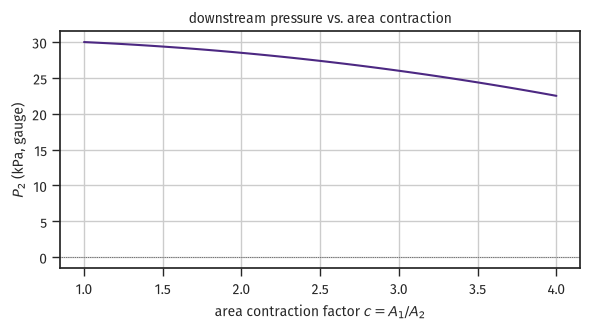

contraction x4: u2 = 4.0 m/s, P2 = 22.5 kPa gauge
P + rho u^2/2 = 30.5 kPa, constant along the channel


In [5]:
# Bernoulli along a converging channel
rho_w = 1000.0
u1, P1 = 1.0, 30e3          # upstream speed (m/s), gauge pressure (Pa)
contraction = np.linspace(1, 4, 100)

u2 = contraction * u1
P2 = P1 + 0.5 * rho_w * (u1**2 - u2**2)

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(contraction, P2 / 1e3)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('area contraction factor $c = A_1/A_2$')
ax.set_ylabel('$P_2$ (kPa, gauge)')
ax.set_title('downstream pressure vs. area contraction')
fig.tight_layout()
plt.show()

c = 4
print(f'contraction x{c}: u2 = {c*u1:.1f} m/s, '
      f'P2 = {(P1 + 0.5*rho_w*(u1**2 - (c*u1)**2))/1e3:.1f} kPa gauge')
print(f'P + rho u^2/2 = {(P1 + 0.5*rho_w*u1**2)/1e3:.1f} kPa, constant along the channel')

## 5. Exercises

1. Rerun the Kelvin-theorem cell with a loop centered at $(1.2, 0)$, well downstream and
   off-axis, so the uniform stream carries it away from the vortex. Does $\Gamma$ still
   hold? Now shrink the loop until it no longer encloses the core. What is $\Gamma$ then,
   and does it stay there?

2. Kelvin's theorem needs the body force to be conservative. Add a fake non-conservative
   forcing to `vel_rankine` (say a term $+\epsilon y\,\hat x$ that does work around a
   circuit), advect the loops again, and measure $d\Gamma/dt$. How large does $\epsilon$
   have to be before the drift is visible against the integration error?

3. Replace the source in Section 3 with a **doublet**,
   $\psi = -\dfrac{\mu\,y}{2\pi(x^2+y^2)}$, and add the uniform stream. Show that the
   dividing streamline is now a closed circle of radius $\sqrt{\mu/(2\pi U)}$: flow past
   a cylinder. Compute the surface speed and confirm it peaks at $2U$ on the shoulders.

4. Bernoulli in the converging channel assumed steady flow. Suppose the upstream speed
   ramps from 1 to 3 m/s over 5 s in a nozzle 2 m long. Estimate $\partial\phi/\partial t$
   and compare it with $\tfrac12 u^2$. At what ramp rate does the unsteady term stop being
   negligible?
